In [ ]:
# Install packages
!pip install netCDF4 astropy

from netCDF4 import Dataset

# Change this to your MAG filename
mag_file = "L2_AL1_MAG_20260607_V00.nc"

ds = Dataset(mag_file)

print("Variables:")
print(ds.variables.keys())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.8 MB/s eta 0:00:00
Variables:
dict_keys(['time', 'Bx_gse', 'By_gse', 'Bz_gse', 'Bx_gsm', 'By_gsm', 'Bz_gsm', 'Bx_gse_error', 'By_gse_error', 'Bz_gse_error', 'Bx_gsm_error', 'By_gsm_error', 'Bz_gsm_error', 'Quality_flag_10s_data', 'x_gse', 'y_gse', 'z_gse', 'x_gsm', 'y_gsm', 'z_gsm'])


Mean Active Region Intensity = 0.6649992200280657


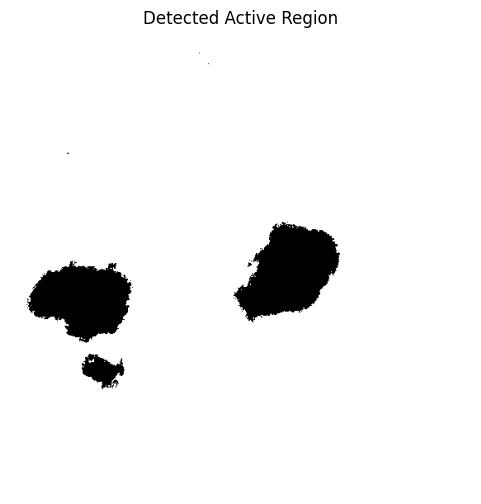

Mean Magnetic Field = 303.720840234144
Pearson Correlation = nan


/tmp/ipykernel_681/3692907704.py:98: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = pearsonr(I,B)


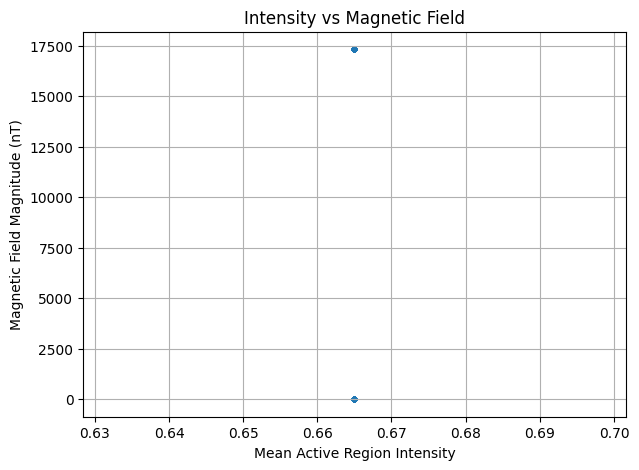

In [ ]:
# ==========================================
# PART 2B
# SUIT + MAG Correlation Analysis
# ==========================================

!pip install astropy netCDF4 scikit-image scipy

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from netCDF4 import Dataset

from skimage.filters import threshold_otsu
from scipy.stats import pearsonr

#############################################
# Load SUIT FITS Image
#############################################

fits_file = "SUT_T26_0961_002231_Lev1.0_2026-06-29T22.11.24.936_08B3NB07.fits"

hdul = fits.open(fits_file)

image = None

for hdu in hdul:
    if hdu.data is not None:
        if len(hdu.data.shape) >= 2:
            image = hdu.data.astype(float)
            break

hdul.close()

#############################################
# Preprocess Image
#############################################

image = np.nan_to_num(image)

image = image - np.min(image)

image = image / np.max(image)

#############################################
# Active Region Segmentation
#############################################

threshold = threshold_otsu(image)

mask = image > threshold

#############################################
# Mean Active Region Intensity
#############################################

mean_intensity = np.mean(image[mask])

print("Mean Active Region Intensity =", mean_intensity)

#############################################
# Display Active Region
#############################################

plt.figure(figsize=(6,6))
plt.imshow(mask,cmap='gray')
plt.title("Detected Active Region")
plt.axis("off")
plt.show()

#############################################
# Load MAG Data
#############################################

mag_file = "L2_AL1_MAG_20260607_V00.nc"

ds = Dataset(mag_file)

Bx = ds.variables['Bx_gse'][:]
By = ds.variables['By_gse'][:]
Bz = ds.variables['Bz_gse'][:]

#############################################
# Magnetic Field Magnitude
#############################################

B = np.sqrt(Bx**2 + By**2 + Bz**2)

print("Mean Magnetic Field =", np.mean(B))

#############################################
# Correlation
#############################################

# Repeat intensity value
I = np.full(len(B),mean_intensity)

r,p = pearsonr(I,B)

print("Pearson Correlation =",r)

#############################################
# Scatter Plot
#############################################

plt.figure(figsize=(7,5))

plt.scatter(I,B,s=10)

plt.xlabel("Mean Active Region Intensity")

plt.ylabel("Magnetic Field Magnitude (nT)")

plt.title("Intensity vs Magnetic Field")

plt.grid(True)

plt.show()